# Projet 2 – Classification de la qualité du vin

**Machine Learning I – ING2-BDML – EFREI 2026/2027**

**Objectif :** prédire si un vin rouge est **bon (qualité ≥ 7)** à partir de ses caractéristiques physico-chimiques.

**Données :** fichier `winequality-red.csv` (1 599 vins rouges, 11 variables, note de qualité de 0 à 10), à placer dans le dossier `data/`.

## 0. Importation des librairies

In [1]:
import numpy as np
np.set_printoptions (suppress=True)
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import seaborn as sns
from collections import Counter
import os
os.makedirs('figures', exist_ok=True)   #dossier des figures du rapport

# 1. Prétraitement des données

## 1.1 Chargement des données et statistiques descriptives

In [2]:
vin=pd.read_csv('data/winequality-red.csv',sep=';',header=0)
#sep=';' : séparateur du fichier ; header=0 : la première ligne contient les titres
vin.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


In [3]:
print(type(vin))
print("Dimensions :", vin.shape)
vin.describe().T

<class 'pandas.DataFrame'>
Dimensions : (1599, 12)


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [4]:
#Répartition de la note de qualité
print(vin['quality'].value_counts().sort_index())

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


Les 11 variables sont continues et d'échelles très différentes (chlorures : 0,087 g/L en moyenne ; SO₂ total : 46,5 mg/L). La qualité varie de 3 à 8 ; la plupart des vins sont notés 5 ou 6.

## 1.2 Valeurs manquantes

In [5]:
print("Valeurs manquantes :")
print(vin.isnull().sum())

Valeurs manquantes :
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Aucune valeur manquante.

## 1.3 Détection des valeurs aberrantes

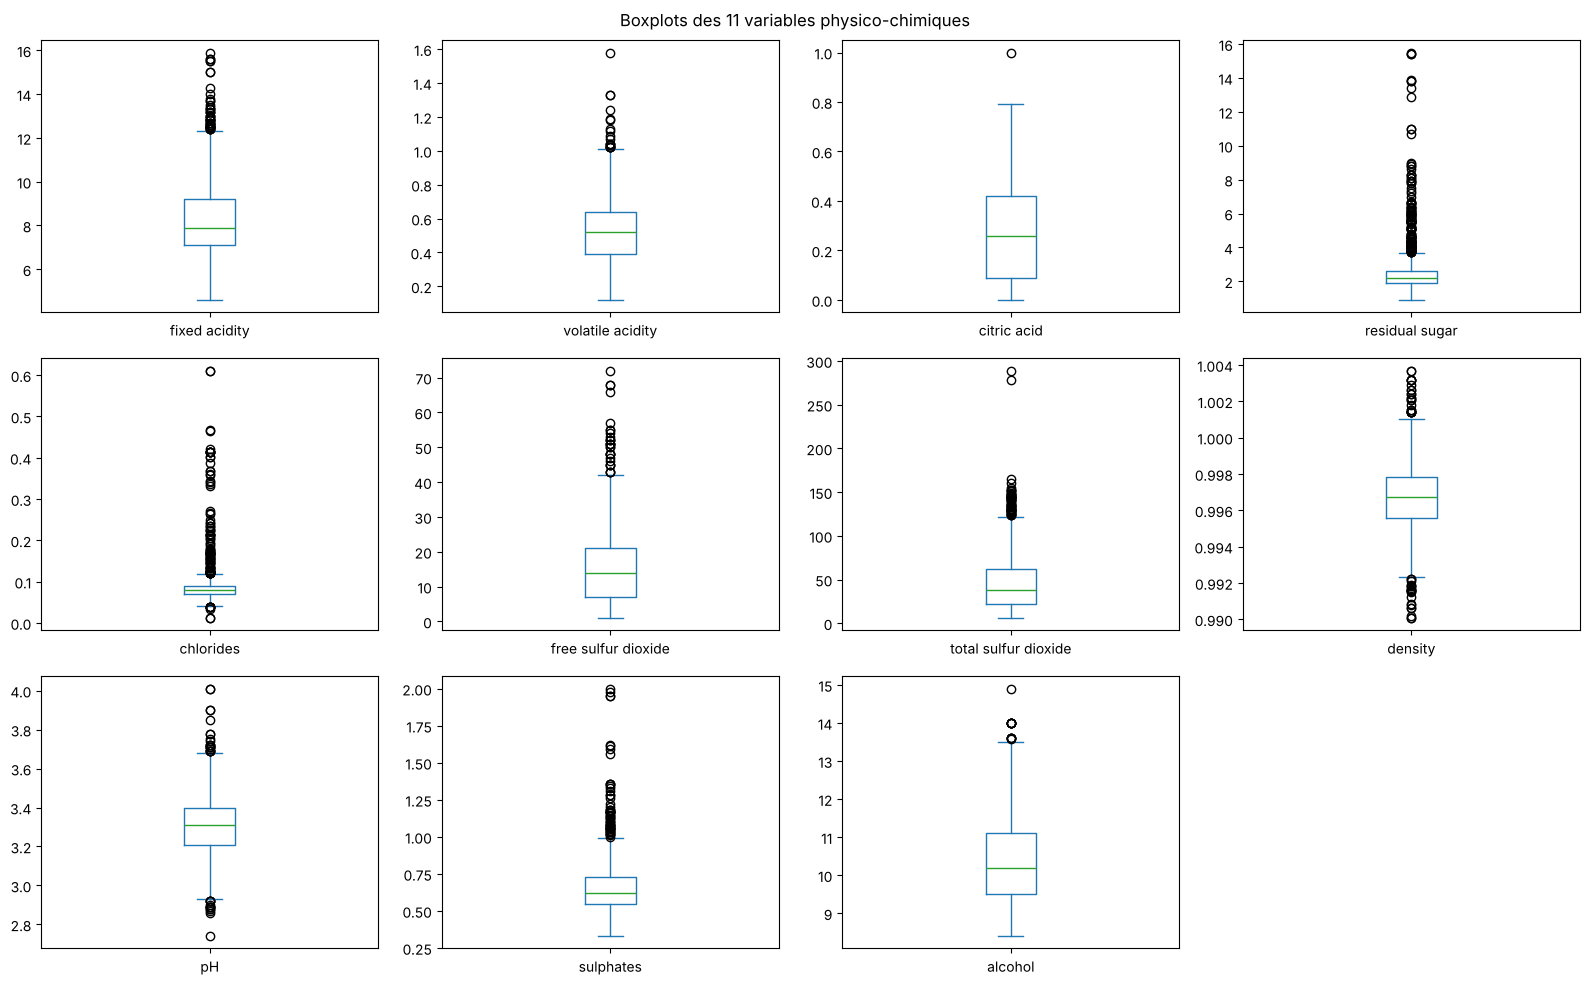

In [6]:
variables=list(vin.columns[:11])
vin[variables].plot(kind='box', subplots=True, layout=(3,4), figsize=(16,10), sharey=False)
plt.suptitle('Boxplots des 11 variables physico-chimiques')
plt.tight_layout(); plt.savefig('figures/01_boxplots.png', dpi=110); plt.show()

In [7]:
#Nombre de valeurs au-delà des moustaches des boxplots
Q1=vin[variables].quantile(0.25)
Q3=vin[variables].quantile(0.75)
IQR=Q3-Q1
aberrant=(vin[variables]<Q1-1.5*IQR)|(vin[variables]>Q3+1.5*IQR)
print(aberrant.sum())
print('\nVins ayant au moins une valeur atypique : {0:.1f} %'.format(100*aberrant.any(axis=1).mean()))

fixed acidity            49
volatile acidity         19
citric acid               1
residual sugar          155
chlorides               112
free sulfur dioxide      30
total sulfur dioxide     55
density                  45
pH                       35
sulphates                59
alcohol                  13
dtype: int64

Vins ayant au moins une valeur atypique : 25.3 %


25,3 % des vins ont au moins une valeur au-delà des moustaches, surtout pour le sucre résiduel, les chlorures, les sulfates et le SO₂ total. Ces variables sont asymétriques et les valeurs restent plausibles : **on les conserve**.

## 1.4 Encodage des variables catégorielles

In [8]:
print(vin.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


Toutes les variables sont numériques : aucun encodage n'est nécessaire.

## 1.5 Transformation en problème de classification binaire
Qualité ≥ 7 → bon vin (classe 1), sinon classe 0.

In [9]:
vin['bon_vin']=(vin['quality']>=7).astype(int)
vin=vin.drop(columns='quality')

#l'initialisation de X : les colonnes qui sont traitées
X=vin[variables].values
#l'initialisation de Y : la colonne qui contient le résultat
Y=vin['bon_vin'].values
print('X :', X.shape, '| Y :', Y.shape)

X : (1599, 11) | Y : (1599,)


## 1.6 Distribution des classes

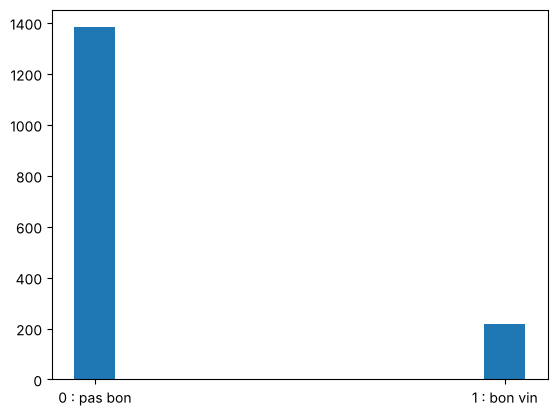

In [10]:
histogram=Counter(Y)
plt.bar(histogram.keys(),histogram.values() , 0.1)
plt.xticks([0,1],['0 : pas bon','1 : bon vin'])
plt.savefig('figures/02_classes.png', dpi=110); plt.show()
#Afficher le nbre d'instance de la colonne Y

In [11]:
ep=np.sum(Y==1)/len(Y)  #len: Total
nep=np.sum(Y==0)/len(Y)
print('Bon vin : {0:.3f} et Non : {1:.3f}'.format(ep,nep))

Bon vin : 0.136 et Non : 0.864


Le jeu est **déséquilibré** : 13,6 % de bons vins. Un modèle qui répond toujours « pas bon » a déjà 86 % d'accuracy : l'accuracy seule est trompeuse. On compare donc les modèles avec la **moyenne de l'accuracy et du rappel**.

## 1.7 Analyse des corrélations

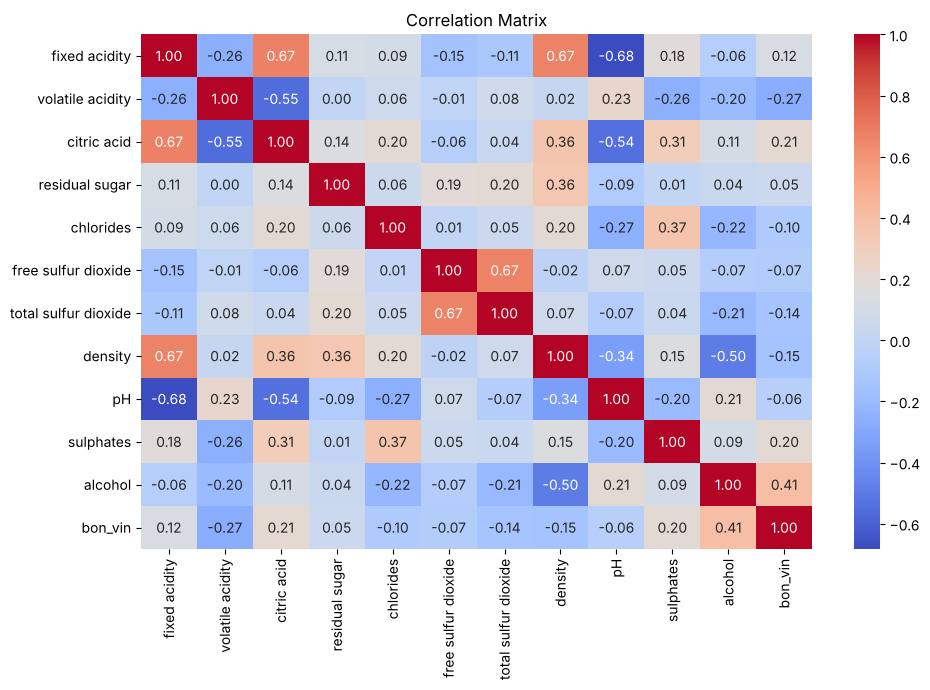

In [12]:
correlation_matrix=vin.corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.tight_layout(); plt.savefig('figures/03_matrice_correlation.png', dpi=110); plt.show()

In [13]:
#Corrélation de chaque variable avec la cible
print(correlation_matrix['bon_vin'].drop('bon_vin').sort_values().round(2))

volatile acidity       -0.27
density                -0.15
total sulfur dioxide   -0.14
chlorides              -0.10
free sulfur dioxide    -0.07
pH                     -0.06
residual sugar          0.05
fixed acidity           0.12
sulphates               0.20
citric acid             0.21
alcohol                 0.41
Name: bon_vin, dtype: float64


- **Avec la cible :** alcool (+0,41), acidité volatile (−0,27), acide citrique (+0,21) et sulfates (+0,20). Le sucre résiduel, le pH et le SO₂ libre n'ont presque pas de lien avec la qualité.
- **Entre variables :** l'acidité fixe est liée à l'acide citrique (+0,67), à la densité (+0,67) et au pH (−0,68) ; le SO₂ libre au SO₂ total (+0,67).
- Ces corrélations contredisent l'hypothèse d'indépendance de Naive Bayes.

## 1.8 Histogrammes

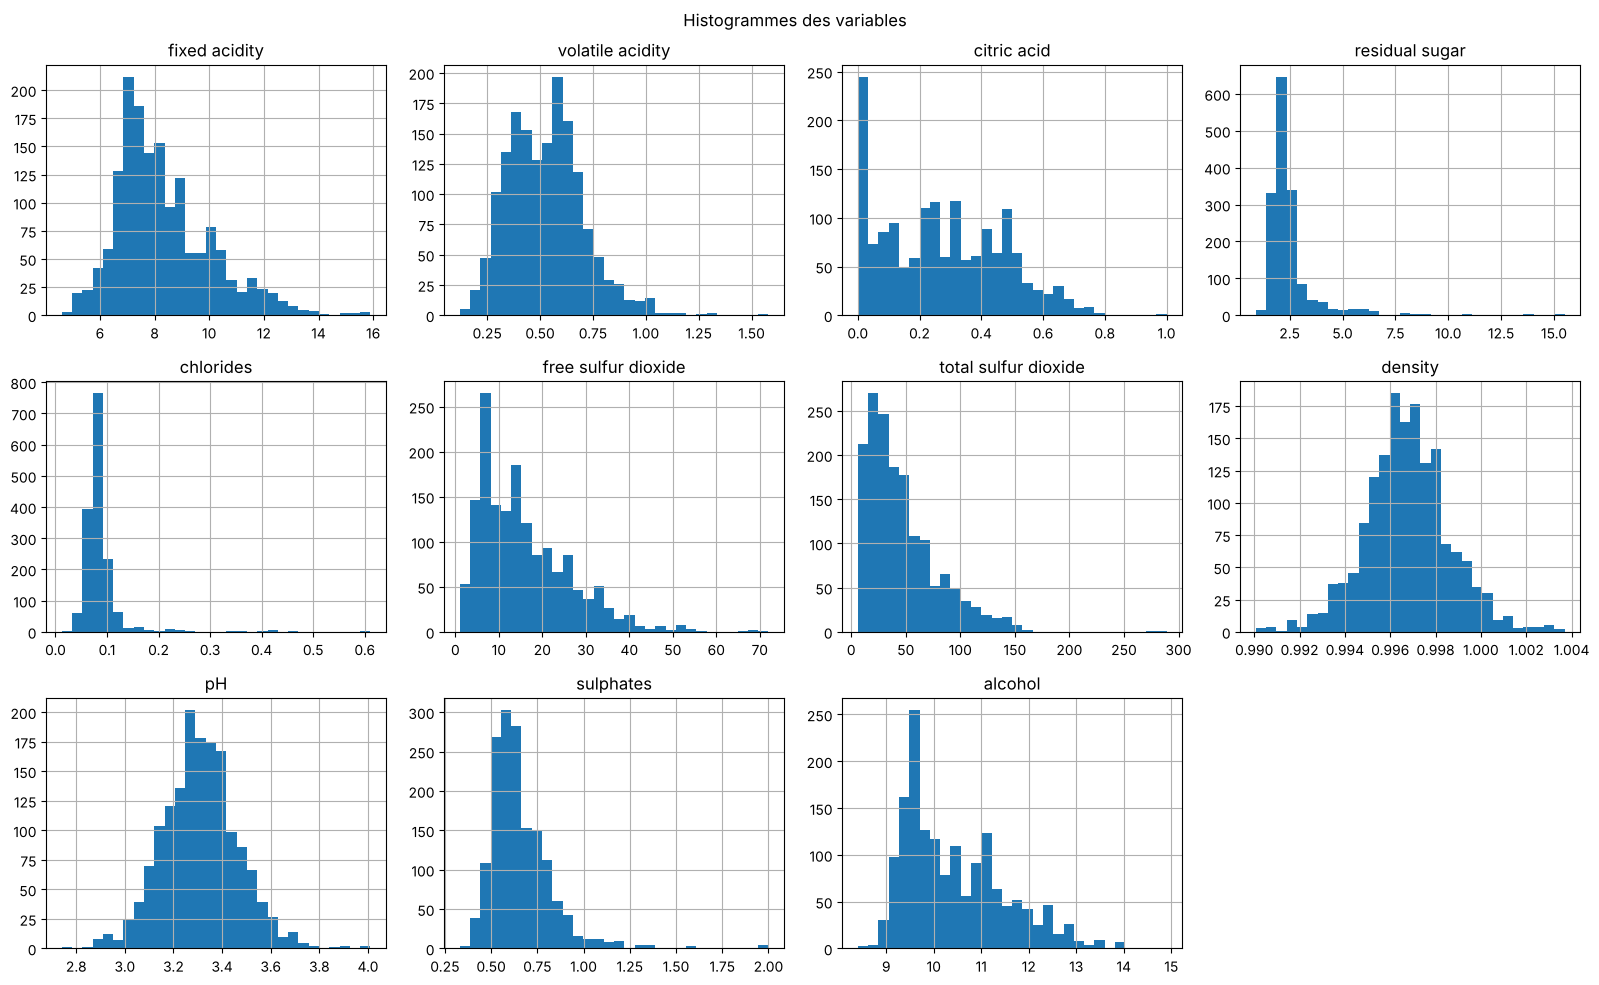

In [14]:
vin[variables].hist(bins=30, figsize=(16,10), layout=(3,4))
plt.suptitle('Histogrammes des variables')
plt.tight_layout(); plt.savefig('figures/04_histogrammes.png', dpi=110); plt.show()

Plusieurs variables sont asymétriques (sucre résiduel, chlorures, SO₂, sulfates) : l'hypothèse gaussienne de Naive Bayes n'est pas respectée.

## 1.9 Séparation des données

In [15]:
from sklearn.model_selection import train_test_split

#Importation des algorithmes
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

#Importation des métriques
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,classification_report
#Importation des Standards de normalisation
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [16]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.25,random_state=1)
#La base de test contiendra 25% des individus de la base totale.
print('Apprentissage :', Xtrain.shape, '| Test :', Xtest.shape)
print('Bons vins - apprentissage : {0:.3f} | test : {1:.3f} ({2} bons vins)'.format(Ytrain.mean(), Ytest.mean(), Ytest.sum()))

Apprentissage : (1199, 11) | Test : (400, 11)
Bons vins - apprentissage : 0.143 | test : 0.113 (45 bons vins)


## 1.10 Normalisation des données avec StandardScaler

In [17]:
ss=StandardScaler()
ss.fit(Xtrain)
Xtrain_norm=ss.transform(Xtrain)
Xtest_norm=ss.transform(Xtest)

## 1.11 Sélection de variables
Méthodes **filter** (Pearson, Chi², information mutuelle), **wrapper** (RFE) et **embedded** (Lasso, Ridge), appliquées à l'apprentissage. Chaque méthode retient 6 variables sur 11 (les coefficients non nuls pour le Lasso). On garde les variables retenues par au moins 3 méthodes sur 6.

In [18]:
from sklearn.feature_selection import chi2, mutual_info_classif, RFE
from sklearn.linear_model import Lasso, Ridge

Xtrain_df=pd.DataFrame(Xtrain,columns=variables)
nb_retenues=6

# --- Filter : Pearson (valeur absolue), Chi² (sur données ramenées dans [0,1]), information mutuelle
pearson=Xtrain_df.corrwith(pd.Series(Ytrain)).abs()
mm=MinMaxScaler().fit(Xtrain)
chi2_scores=pd.Series(chi2(mm.transform(Xtrain),Ytrain)[0],index=variables)
mi=pd.Series(mutual_info_classif(Xtrain,Ytrain,random_state=0),index=variables)

# --- Wrapper : RFE avec une régression logistique (données normalisées)
rfe=RFE(LogisticRegression(max_iter=1000),n_features_to_select=nb_retenues).fit(Xtrain_norm,Ytrain)

# --- Embedded : Lasso et Ridge (données normalisées)
lasso_coef=pd.Series(Lasso(alpha=0.01).fit(Xtrain_norm,Ytrain).coef_,index=variables)
ridge_coef=pd.Series(Ridge(alpha=1.0).fit(Xtrain_norm,Ytrain).coef_,index=variables)

pd.DataFrame({'|Pearson|':pearson,'Chi2':chi2_scores,'Info. mutuelle':mi,'Rang RFE':rfe.ranking_,
              'Coef. Lasso':lasso_coef,'Coef. Ridge':ridge_coef}).round(3).sort_values('|Pearson|',ascending=False)

,|Pearson|,Chi2,Info. mutuelle,Rang RFE,Coef. Lasso,Coef. Ridge
alcohol,0.405,17.030,0.101,1,0.115,0.087
volatile acidity,0.291,5.442,0.062,1,-0.045,-0.039
citric acid,0.216,8.221,0.040,6,0.008,0.012
sulphates,0.207,2.666,0.071,1,0.041,0.062
density,0.160,1.280,0.032,2,-0.000,-0.061
total sulfur dioxide,0.142,2.351,0.041,1,-0.017,-0.029
fixed acidity,0.117,1.249,0.065,1,0.000,0.047
chlorides,0.108,0.672,0.021,1,-0.022,-0.038
pH,0.074,0.223,0.010,5,-0.025,-0.015
free sulfur dioxide,0.066,0.541,0.011,4,-0.000,0.001


In [19]:
selection=pd.DataFrame(index=variables)
selection['Pearson']=pearson.rank(ascending=False)<=nb_retenues
selection['Chi2']=chi2_scores.rank(ascending=False)<=nb_retenues
selection['Info. mutuelle']=mi.rank(ascending=False)<=nb_retenues
selection['RFE']=rfe.support_
selection['Lasso']=lasso_coef.abs()>0
selection['Ridge']=ridge_coef.abs().rank(ascending=False)<=nb_retenues
selection['Nb votes']=selection.sum(axis=1)
print(selection.sort_values('Nb votes',ascending=False).astype(int))

                      Pearson  Chi2  Info. mutuelle  RFE  Lasso  Ridge  \
volatile acidity            1     1               1    1      1      1   
alcohol                     1     1               1    1      1      1   
sulphates                   1     1               1    1      1      1   
total sulfur dioxide        1     1               1    1      1      0   
citric acid                 1     1               1    0      1      0   
fixed acidity               0     0               1    1      0      1   
chlorides                   0     0               0    1      1      1   
density                     1     1               0    0      0      1   
pH                          0     0               0    0      1      0   
free sulfur dioxide         0     0               0    0      0      0   
residual sugar              0     0               0    0      0      0   

                      Nb votes  
volatile acidity             6  
alcohol                      6  
sulphates   

In [20]:
variables_selectionnees=[v for v in variables if selection.loc[v,'Nb votes']>=3]
print('Variables retenues :', len(variables_selectionnees), variables_selectionnees)
print('Variables écartées :', [v for v in variables if v not in variables_selectionnees])

Variables retenues : 8 ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'total sulfur dioxide', 'density', 'sulphates', 'alcohol']
Variables écartées : ['residual sugar', 'free sulfur dioxide', 'pH']


**8 variables retenues.** Le pH, le SO₂ libre et le sucre résiduel, peu liés à la qualité, sont écartés. La suite utilise ces 8 variables ; la normalisation est refaite sur elles.

In [21]:
idx=[variables.index(v) for v in variables_selectionnees]
Xtrain_sel=Xtrain[:,idx]
Xtest_sel=Xtest[:,idx]

ss_sel=StandardScaler()
ss_sel.fit(Xtrain_sel)
Xtrain_sel_norm=ss_sel.transform(Xtrain_sel)
Xtest_sel_norm=ss_sel.transform(Xtest_sel)
print('Apprentissage :', Xtrain_sel_norm.shape, '| Test :', Xtest_sel_norm.shape)

Apprentissage : (1199, 8) | Test : (400, 8)


# 2. Modélisation

## 2.1 Choix des modèles

| Modèle | Linéaire ? | Justification |
|---|---|---|
| Arbre de décision (`entropy`) | Non | Insensible à l'échelle et aux valeurs atypiques ; risque de sur-apprentissage |
| Naive Bayes | Non | Simple, mais suppose des variables indépendantes et gaussiennes |
| Régression logistique | Oui | Frontière linéaire, sortie probabiliste |
| k-NN (k = 1, 3, 5, 7) | Non | Basé sur une distance : normalisation nécessaire, sensible au bruit |
| SVM linéaire | Oui | Hyperplan de marge maximale |
| SVM `rbf`, `sigmoid`, `poly` (degré 2) | Non | Frontière non linéaire grâce au noyau |

## 2.2 Fonction de comparaison des modèles
La fonction entraîne un modèle et calcule l'accuracy, le rappel et leur moyenne, ainsi que la précision, le F1, l'AUC et les résultats sur l'apprentissage.

In [22]:
def evaluer_modele(nom, modele, Xtr, Ytr, Xte, Yte, afficher=True):
    modele.fit(Xtr,Ytr)
    Ypred=modele.predict(Xte)
    Ypred_train=modele.predict(Xtr)
    if hasattr(modele,'predict_proba'):
        score=modele.predict_proba(Xte)[:,1]
    else:
        score=modele.decision_function(Xte)
    acc=accuracy_score(Yte,Ypred)
    rec=recall_score(Yte,Ypred)
    acc_train=accuracy_score(Ytr,Ypred_train)
    rec_train=recall_score(Ytr,Ypred_train)
    if afficher:
        print ('************* Performance Evaluation of '+nom+' *************')
        print(confusion_matrix(Yte,Ypred))
        print(classification_report(Yte,Ypred,zero_division=0))
    return {'Modèle':nom,
            'Accuracy':acc,
            'Précision':precision_score(Yte,Ypred,zero_division=0),
            'Rappel':rec,
            'F1':f1_score(Yte,Ypred),
            'AUC':roc_auc_score(Yte,score),
            'Moy. acc+rappel':(acc+rec)/2,
            'Accuracy train':acc_train,
            'Moy. acc+rappel train':(acc_train+rec_train)/2}

def creer_modeles():
    return {'Arbre de décision':DecisionTreeClassifier(random_state=0, criterion='entropy'),
            'Naive Bayes':GaussianNB(),
            'Régression logistique':LogisticRegression(max_iter=1000),
            'KNN (K=1)':KNeighborsClassifier(n_neighbors=1),
            'KNN (K=3)':KNeighborsClassifier(n_neighbors=3),
            'KNN (K=5)':KNeighborsClassifier(n_neighbors=5),
            'KNN (K=7)':KNeighborsClassifier(n_neighbors=7),
            'Linear SVM':SVC(kernel='linear'),
            'RBF SVM':SVC(kernel='rbf'),
            'Sigmoid SVM':SVC(kernel='sigmoid'),
            'Polynomial (2) SVM':SVC(kernel='poly',degree=2)}

def tableau(resultats):
    return pd.DataFrame(resultats).set_index('Modèle').round(3).sort_values('Moy. acc+rappel',ascending=False)

## 2.3 Apprentissage sans normalisation

In [23]:
resultats_bruts=[]
for nom,modele in creer_modeles().items():
    resultats_bruts.append(evaluer_modele(nom,modele,Xtrain_sel,Ytrain,Xtest_sel,Ytest,afficher=False))
tab_bruts=tableau(resultats_bruts)
tab_bruts

,Accuracy,Précision,Rappel,F1,AUC,Moy. acc+rappel,Accuracy train,Moy. acc+rappel train
Modèle,,,,,,,,
Naive Bayes,0.838,0.381,0.711,0.496,0.838,0.774,0.847,0.770
Arbre de décision,0.875,0.456,0.578,0.510,0.745,0.726,1.000,1.000
KNN (K=1),0.868,0.417,0.444,0.430,0.683,0.656,1.000,1.000
KNN (K=5),0.900,0.586,0.378,0.459,0.727,0.639,0.902,0.695
KNN (K=3),0.885,0.486,0.378,0.425,0.706,0.631,0.921,0.771
KNN (K=7),0.898,0.583,0.311,0.406,0.760,0.604,0.894,0.651
Régression logistique,0.895,0.560,0.311,0.400,0.869,0.603,0.873,0.585
RBF SVM,0.890,1.000,0.022,0.043,0.851,0.456,0.857,0.432
Linear SVM,0.888,0.000,0.000,0.000,0.862,0.444,0.857,0.428


## 2.4 Apprentissage après normalisation

In [24]:
resultats_norm=[]
for nom,modele in creer_modeles().items():
    resultats_norm.append(evaluer_modele(nom,modele,Xtrain_sel_norm,Ytrain,Xtest_sel_norm,Ytest))

************* Performance Evaluation of Arbre de décision *************
[[325  30]
 [ 19  26]]
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       355
           1       0.46      0.58      0.51        45

    accuracy                           0.88       400
   macro avg       0.70      0.75      0.72       400
weighted avg       0.89      0.88      0.88       400

************* Performance Evaluation of Naive Bayes *************
[[300  55]
 [ 13  32]]
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       355
           1       0.37      0.71      0.48        45

    accuracy                           0.83       400
   macro avg       0.66      0.78      0.69       400
weighted avg       0.89      0.83      0.85       400

************* Performance Evaluation of Régression logistique *************
[[342  13]
 [ 32  13]]
              precision    recall  f1-score   support

        

************* Performance Evaluation of Linear SVM *************
[[355   0]
 [ 45   0]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       355
           1       0.00      0.00      0.00        45

    accuracy                           0.89       400
   macro avg       0.44      0.50      0.47       400
weighted avg       0.79      0.89      0.83       400

************* Performance Evaluation of RBF SVM *************
[[348   7]
 [ 31  14]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       355
           1       0.67      0.31      0.42        45

    accuracy                           0.91       400
   macro avg       0.79      0.65      0.69       400
weighted avg       0.89      0.91      0.89       400

************* Performance Evaluation of Sigmoid SVM *************
[[318  37]
 [ 31  14]]
              precision    recall  f1-score   support

           0       0.91      

In [25]:
tab_norm=tableau(resultats_norm)
tab_norm

,Accuracy,Précision,Rappel,F1,AUC,Moy. acc+rappel,Accuracy train,Moy. acc+rappel train
Modèle,,,,,,,,
Naive Bayes,0.830,0.368,0.711,0.485,0.839,0.771,0.841,0.766
KNN (K=1),0.870,0.443,0.600,0.509,0.752,0.735,1.000,1.000
Arbre de décision,0.878,0.464,0.578,0.515,0.747,0.728,1.000,1.000
KNN (K=5),0.898,0.543,0.556,0.549,0.881,0.727,0.917,0.752
KNN (K=7),0.888,0.500,0.467,0.483,0.870,0.677,0.902,0.712
KNN (K=3),0.872,0.429,0.400,0.414,0.793,0.636,0.934,0.833
RBF SVM,0.905,0.667,0.311,0.424,0.841,0.608,0.893,0.621
Régression logistique,0.888,0.500,0.289,0.366,0.864,0.588,0.874,0.594
Sigmoid SVM,0.830,0.275,0.311,0.292,0.726,0.571,0.813,0.552


In [26]:
#Effet de la normalisation
pd.DataFrame({'Moy. acc+rappel sans normalisation':tab_bruts['Moy. acc+rappel'],
              'Moy. acc+rappel avec normalisation':tab_norm['Moy. acc+rappel']}).loc[list(creer_modeles().keys())]

,Moy. acc+rappel sans normalisation,Moy. acc+rappel avec normalisation
Modèle,,
Arbre de décision,0.726,0.728
Naive Bayes,0.774,0.771
Régression logistique,0.603,0.588
KNN (K=1),0.656,0.735
KNN (K=3),0.631,0.636
KNN (K=5),0.639,0.727
KNN (K=7),0.604,0.677
Linear SVM,0.444,0.444
RBF SVM,0.456,0.608


- Le k-NN et les SVM `rbf` et `sigmoid` progressent : ils dépendent des distances.
- L'arbre et Naive Bayes ne changent presque pas.
- Le SVM linéaire et le SVM polynomial prédisent « pas bon » pour tous les vins, avec ou sans normalisation.

On garde les données normalisées.

# 3. Évaluation des modèles

## 3.1 Comparaison des performances

In [27]:
tab_norm[['Accuracy','Précision','Rappel','F1','AUC','Moy. acc+rappel']]

,Accuracy,Précision,Rappel,F1,AUC,Moy. acc+rappel
Modèle,,,,,,
Naive Bayes,0.830,0.368,0.711,0.485,0.839,0.771
KNN (K=1),0.870,0.443,0.600,0.509,0.752,0.735
Arbre de décision,0.878,0.464,0.578,0.515,0.747,0.728
KNN (K=5),0.898,0.543,0.556,0.549,0.881,0.727
KNN (K=7),0.888,0.500,0.467,0.483,0.870,0.677
KNN (K=3),0.872,0.429,0.400,0.414,0.793,0.636
RBF SVM,0.905,0.667,0.311,0.424,0.841,0.608
Régression logistique,0.888,0.500,0.289,0.366,0.864,0.588
Sigmoid SVM,0.830,0.275,0.311,0.292,0.726,0.571


- **Naive Bayes** est le meilleur (0,771) grâce à son rappel : il détecte 32 bons vins sur 45.
- L'accuracy est trompeuse : le SVM linéaire et le SVM polynomial obtiennent 0,888 sans détecter aucun bon vin.
- Le SVM `rbf` et la régression logistique sont précis mais détectent peu de bons vins (rappel ≈ 0,3).

## 3.2 Courbes ROC et AUC

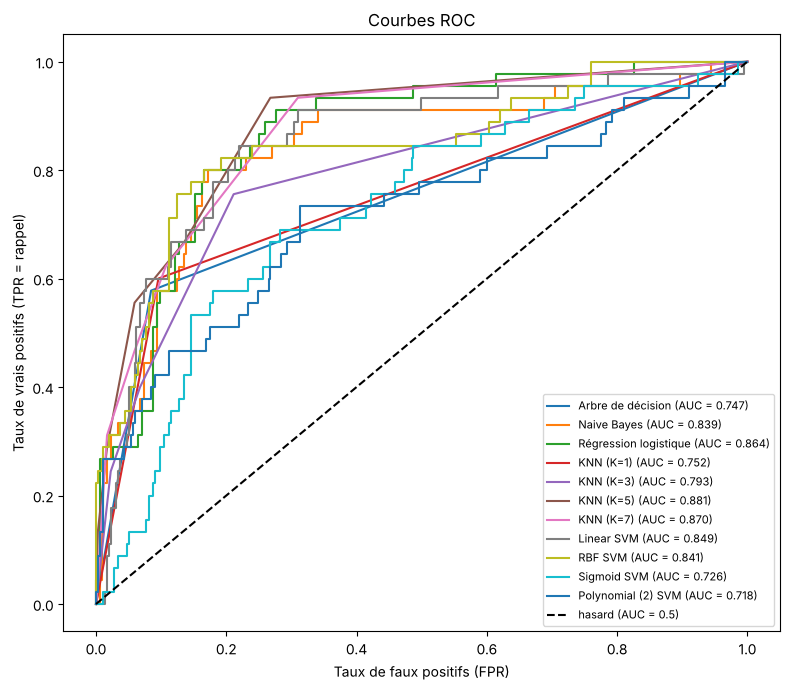

In [28]:
plt.figure(figsize=(8,7))
for nom,modele in creer_modeles().items():
    modele.fit(Xtrain_sel_norm,Ytrain)
    if hasattr(modele,'predict_proba'):
        score=modele.predict_proba(Xtest_sel_norm)[:,1]
    else:
        score=modele.decision_function(Xtest_sel_norm)
    fpr,tpr,seuils=roc_curve(Ytest,score)
    plt.plot(fpr,tpr,label='{0} (AUC = {1:.3f})'.format(nom,roc_auc_score(Ytest,score)))
plt.plot([0,1],[0,1],'k--',label='hasard (AUC = 0.5)')
plt.xlabel('Taux de faux positifs (FPR)'); plt.ylabel('Taux de vrais positifs (TPR = rappel)')
plt.title('Courbes ROC'); plt.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.savefig('figures/05_roc.png', dpi=110); plt.show()

- Meilleures AUC : k-NN avec k = 5 (0,881) et k = 7 (0,870), régression logistique (0,864).
- La régression logistique et le SVM linéaire ont une bonne AUC mais un rappel faible : c'est le seuil de décision qui pénalise les bons vins, pas le score du modèle.

## 3.3 Compromis biais / variance

In [29]:
biais_variance=tab_norm[['Accuracy train','Accuracy','Moy. acc+rappel train','Moy. acc+rappel']].copy()
biais_variance.columns=['Accuracy train','Accuracy test','Moy. acc+rappel train','Moy. acc+rappel test']
biais_variance['Écart train - test']=biais_variance['Moy. acc+rappel train']-biais_variance['Moy. acc+rappel test']
biais_variance.round(3)

,Accuracy train,Accuracy test,Moy. acc+rappel train,Moy. acc+rappel test,Écart train - test
Modèle,,,,,
Naive Bayes,0.841,0.830,0.766,0.771,-0.005
KNN (K=1),1.000,0.870,1.000,0.735,0.265
Arbre de décision,1.000,0.878,1.000,0.728,0.272
KNN (K=5),0.917,0.898,0.752,0.727,0.025
KNN (K=7),0.902,0.888,0.712,0.677,0.035
KNN (K=3),0.934,0.872,0.833,0.636,0.197
RBF SVM,0.893,0.905,0.621,0.608,0.013
Régression logistique,0.874,0.888,0.594,0.588,0.006
Sigmoid SVM,0.813,0.830,0.552,0.571,-0.019


- **Arbre et k-NN (k = 1)** : score parfait sur l'apprentissage et écart d'environ 0,27 → **sur-apprentissage** (variance).
- **k-NN** : l'écart diminue quand k augmente.
- **Régression logistique et SVM** : écart proche de 0 mais scores faibles → **biais**.
- **Naive Bayes** : écart nul et meilleur score → meilleur compromis parmi les modèles de base.

# 4. Optimisation des hyperparamètres

- **Grid Search** pour la régression logistique et le SVM ; **Random Search** (30 tirages) pour l'arbre et le k-NN.
- Validation croisée à 5 plis sur l'apprentissage ; critère : moyenne de l'accuracy et du rappel.
- `class_weight='balanced'` donne plus de poids aux bons vins (classe minoritaire).
- Naive Bayes est utilisé sans hyperparamètre.

In [30]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer

#Critère : moyenne de l'accuracy et du rappel
def moyenne_acc_rappel(y_vrai, y_pred):
    return (accuracy_score(y_vrai,y_pred)+recall_score(y_vrai,y_pred))/2
critere=make_scorer(moyenne_acc_rappel)

## 4.1 Grid Search

In [31]:
gs_lr=GridSearchCV(LogisticRegression(max_iter=1000),
                   {'C':[0.01,0.1,1,10,100],'class_weight':[None,'balanced']},
                   cv=5, scoring=critere)
gs_lr.fit(Xtrain_sel_norm,Ytrain)
print('Régression logistique :', gs_lr.best_params_, '| Moy. acc+rappel (CV) = {0:.3f}'.format(gs_lr.best_score_))

gs_svm=GridSearchCV(SVC(degree=2),
                    {'kernel':['linear','rbf','sigmoid','poly'],'C':[0.1,1,10,100],'class_weight':[None,'balanced']},
                    cv=5, scoring=critere)
gs_svm.fit(Xtrain_sel_norm,Ytrain)
print('SVM :', gs_svm.best_params_, '| Moy. acc+rappel (CV) = {0:.3f}'.format(gs_svm.best_score_))

Régression logistique : {'C': 10, 'class_weight': 'balanced'} | Moy. acc+rappel (CV) = 0.796


SVM : {'C': 1, 'class_weight': 'balanced', 'kernel': 'linear'} | Moy. acc+rappel (CV) = 0.791


In [32]:
#Meilleur score de chaque noyau du SVM
pd.DataFrame(gs_svm.cv_results_).groupby('param_kernel')['mean_test_score'].max().round(3)

param_kernel
linear     0.791
poly       0.690
rbf        0.784
sigmoid    0.742
Name: mean_test_score, dtype: float64

## 4.2 Random Search

In [33]:
rs_arbre=RandomizedSearchCV(DecisionTreeClassifier(random_state=0, criterion='entropy'),
                            {'max_depth':list(range(2,21))+[None],
                             'min_samples_split':list(range(2,21)),
                             'min_samples_leaf':list(range(1,21)),
                             'class_weight':[None,'balanced']},
                            n_iter=30, cv=5, scoring=critere, random_state=0)
rs_arbre.fit(Xtrain_sel_norm,Ytrain)
print('Arbre de décision :', rs_arbre.best_params_, '| Moy. acc+rappel (CV) = {0:.3f}'.format(rs_arbre.best_score_))

rs_knn=RandomizedSearchCV(KNeighborsClassifier(),
                          {'n_neighbors':list(range(1,51)),'weights':['uniform','distance'],'p':[1,2]},
                          n_iter=30, cv=5, scoring=critere, random_state=0)
rs_knn.fit(Xtrain_sel_norm,Ytrain)
print('KNN :', rs_knn.best_params_, '| Moy. acc+rappel (CV) = {0:.3f}'.format(rs_knn.best_score_))

Arbre de décision : {'min_samples_split': 15, 'min_samples_leaf': 1, 'max_depth': 8, 'class_weight': 'balanced'} | Moy. acc+rappel (CV) = 0.798


KNN : {'weights': 'distance', 'p': 1, 'n_neighbors': 12} | Moy. acc+rappel (CV) = 0.745


## 4.3 Évaluation des modèles optimisés par validation croisée
Score moyen et écart-type en validation croisée, et score sur l'apprentissage. Le test n'est pas utilisé ici.

In [34]:
optimisations={'Régression logistique':gs_lr,'SVM':gs_svm,'Arbre de décision':rs_arbre,'KNN':rs_knn}
lignes=[]
for nom,recherche in optimisations.items():
    Ypred_train=recherche.best_estimator_.predict(Xtrain_sel_norm)
    lignes.append({'Modèle':nom,
                   'Meilleurs hyperparamètres':recherche.best_params_,
                   'Moy. acc+rappel (CV)':recherche.best_score_,
                   'Écart-type (CV)':recherche.cv_results_['std_test_score'][recherche.best_index_],
                   'Moy. acc+rappel train':moyenne_acc_rappel(Ytrain,Ypred_train)})
tab_opt=pd.DataFrame(lignes).set_index('Modèle')
tab_opt['Écart train - CV']=tab_opt['Moy. acc+rappel train']-tab_opt['Moy. acc+rappel (CV)']
tab_opt.round(3).sort_values('Moy. acc+rappel (CV)',ascending=False)

,Meilleurs hyperparamètres,Moy. acc+rappel (CV),Écart-type (CV),Moy. acc+rappel train,Écart train - CV
Modèle,,,,,
Arbre de décision,"{'min_samples_split': 15, 'min_samples_leaf': ...",0.798,0.064,0.934,0.136
Régression logistique,"{'C': 10, 'class_weight': 'balanced'}",0.796,0.032,0.796,-0.000
SVM,"{'C': 1, 'class_weight': 'balanced', 'kernel':...",0.791,0.045,0.797,0.006
KNN,"{'weights': 'distance', 'p': 1, 'n_neighbors':...",0.745,0.051,1.000,0.255


- `class_weight='balanced'` est retenu par les trois modèles qui l'acceptent.
- Pour le SVM, le noyau linéaire est le meilleur.
- Régression logistique et SVM : même score en apprentissage et en validation → pas de variance.
- L'arbre (écart 0,136) et le k-NN (écart 0,255) sur-apprennent encore.
- Les trois meilleurs (0,791 à 0,798) sont équivalents : leurs différences sont plus petites que les écarts-types (0,032 à 0,064).

## 4.4 Choix du modèle final
Parmi les modèles à moins d'un écart-type du meilleur, on garde celui dont l'écart entre apprentissage et validation est le plus faible (compromis biais / variance).

In [35]:
meilleur=tab_opt['Moy. acc+rappel (CV)'].max()
ecart_type=tab_opt.loc[tab_opt['Moy. acc+rappel (CV)'].idxmax(),'Écart-type (CV)']
candidats=tab_opt[tab_opt['Moy. acc+rappel (CV)']>=meilleur-ecart_type]
print('Modèles équivalents :', list(candidats.index))
nom_final=candidats['Écart train - CV'].idxmin()
print('Modèle retenu :', nom_final, optimisations[nom_final].best_params_)

Modèles équivalents : ['Régression logistique', 'SVM', 'Arbre de décision', 'KNN']
Modèle retenu : Régression logistique {'C': 10, 'class_weight': 'balanced'}


In [36]:
#Évaluation finale sur le test
modele_final=optimisations[nom_final].best_estimator_
resultat_final=evaluer_modele(nom_final+' optimisé',modele_final,Xtrain_sel_norm,Ytrain,Xtest_sel_norm,Ytest)
pd.DataFrame([resultat_final]).set_index('Modèle').round(3)

************* Performance Evaluation of Régression logistique optimisé *************
[[274  81]
 [  7  38]]
              precision    recall  f1-score   support

           0       0.98      0.77      0.86       355
           1       0.32      0.84      0.46        45

    accuracy                           0.78       400
   macro avg       0.65      0.81      0.66       400
weighted avg       0.90      0.78      0.82       400



,Accuracy,Précision,Rappel,F1,AUC,Moy. acc+rappel,Accuracy train,Moy. acc+rappel train
Modèle,,,,,,,,
Régression logistique optimisé,0.78,0.319,0.844,0.463,0.869,0.812,0.783,0.796


**Modèle retenu : régression logistique** (`C=10`, `class_weight='balanced'`).

Sur le test : moyenne accuracy + rappel de **0,812**, rappel de **0,844** (38 bons vins sur 45), précision de 0,319 (81 fausses alertes), AUC de 0,869. Le score est proche de celui de la validation croisée (0,796) : pas de sur-apprentissage. Le test ne contient que 45 bons vins, ces métriques restent donc incertaines.

In [37]:
#Sauvegarde du modèle final pour l'application web
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump({'normalisation':ss_sel,'modele':modele_final,'variables':variables_selectionnees,'nom':nom_final},
            'models/modele_final.joblib')
print('Modèle sauvegardé dans models/modele_final.joblib')

Modèle sauvegardé dans models/modele_final.joblib


# 5. Conclusion

- Le jeu est déséquilibré (13,6 % de bons vins) : la moyenne de l'accuracy et du rappel est plus adaptée que l'accuracy seule.
- 8 variables sur 11 sont retenues ; la normalisation est indispensable pour le k-NN et les SVM.
- `class_weight='balanced'` corrige le déséquilibre : le rappel de la régression logistique passe de 0,289 à 0,844.
- Modèle retenu : **régression logistique**, avec 0,812 sur le test et 38 bons vins détectés sur 45, mais une précision faible (0,319).